In [1]:
# Imports necessary programs, as well as the dataset to be worked with.
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
cafedata = pd.DataFrame(pd.read_csv('dirty_cafe_sales.csv'))
pd.set_option('display.max_columns', None)

In [2]:
# A preliminary sample of our dirty data to get a taste of what we're looking at. Unknowns, errors, and the like are everywhere here. 
cafedata.sample(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
6930,TXN_8240436,Salad,5,5.0,25.0,NaN,In-store,2023-07-05
8391,TXN_8932087,UNKNOWN,UNKNOWN,3.0,3.0,Digital Wallet,Takeaway,2023-10-30
3955,TXN_8244640,Cookie,1,1.0,1.0,ERROR,Takeaway,2023-09-24
7650,TXN_4363360,Smoothie,1,4.0,ERROR,Credit Card,NaN,2023-12-22
839,TXN_7585348,Cake,3,3.0,9.0,Credit Card,Takeaway,2023-03-16
3517,TXN_2989533,Salad,5,5.0,25.0,NaN,Takeaway,2023-01-30
6516,TXN_3272946,Salad,3,5.0,15.0,Credit Card,In-store,2023-09-06
8709,TXN_7371295,UNKNOWN,3,3.0,9.0,NaN,NaN,2023-03-28
342,TXN_9472241,Salad,3,5.0,15.0,Cash,Takeaway,2023-06-30
5065,TXN_3339728,Juice,5,3.0,15.0,NaN,In-store,2023-05-13


In [3]:
# Sorts values by Transaction ID to obtain an estimated date order, and replaces all missing values with np.nan to make later calculations much easier.
cafedata.sort_values(by='Transaction ID', inplace=True)
cafedata.reset_index(drop=True, inplace=True)
cafedata.replace(['UNKNOWN', 'ERROR'], np.nan, inplace=True)

In [4]:
# Establishes a canon price guide according to the website source, then fills accordingly for item price when it can.
price_guide = {
    'Sandwich': 4.0,
    'Tea': 1.5,
    'Coffee': 2.0,
    'Salad': 5.0,
    'Cake': 3.0,
    'Cookie': 1.0,
    'Smoothie': 4.0,
    'Juice': 3.0
}
for i in range(len(cafedata)):
    if cafedata['Item'].values[i] in price_guide.keys():
        cafedata['Price Per Unit'].values[i] = price_guide[cafedata['Item'].values[i]]

In [5]:
# Sets the numeric values to floats, then uses their dependence on each other to fill in missing values when only one of three values is missing.
cafedata[['Quantity', 'Total Spent', 'Price Per Unit']] = cafedata[['Quantity', 'Total Spent', 'Price Per Unit']].astype(float)
cafedata.fillna({'Quantity': cafedata['Total Spent'] / cafedata['Price Per Unit']}, inplace=True)
cafedata.fillna({'Price Per Unit': cafedata['Total Spent'] / cafedata['Quantity']}, inplace=True)
cafedata.fillna({'Total Spent': cafedata['Quantity'] * cafedata['Price Per Unit']}, inplace=True)

In [6]:
# Fills null dates with the previous transaction's date to attempt to get the values close enough - unfortunately, the Transaction IDs aren't in date order! Then sets the format to datetime.
cafedata['Transaction Date'] = cafedata['Transaction Date'].ffill()
cafedata['Transaction Date'] = pd.to_datetime(cafedata['Transaction Date'])

In [7]:
# For uniquely priced items, retroactively sets the item value from the price per item.
for i in range(len(cafedata)):
    if cafedata['Price Per Unit'].values[i] in [1.0, 1.5, 2.0, 5.0]:
        cafedata['Item'].values[i] = list(price_guide.keys())[list(price_guide.values()).index(cafedata['Price Per Unit'].values[i])]

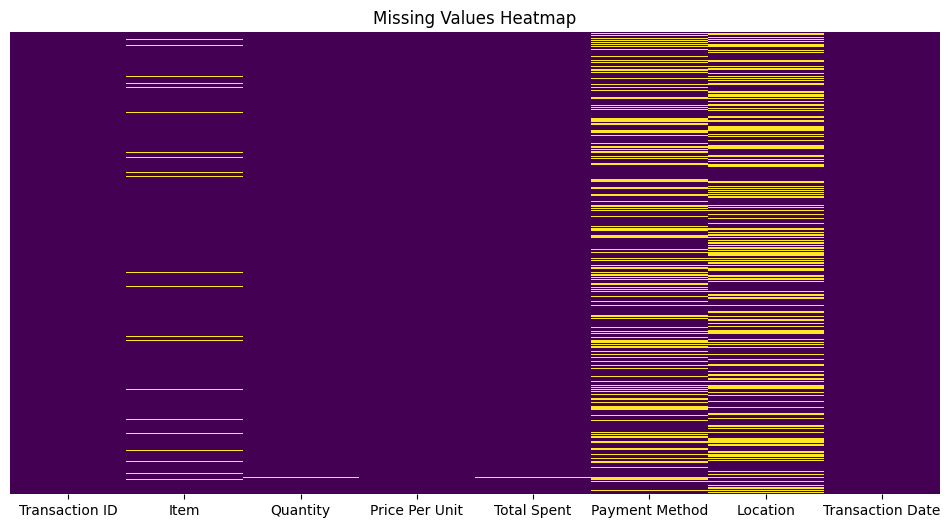

In [8]:
# Visualize missingness
plt.figure(figsize=(12,6))
sns.heatmap(cafedata.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [9]:
# Investigating the remaining missing Quantity data, we can reason with a few remaining missing data points and impute the rest.
cafedata[cafedata['Price Per Unit'].isna()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
87,TXN_1082717,NaN,NaN,NaN,9.0,Digital Wallet,In-store,2023-12-13
206,TXN_1208561,NaN,NaN,NaN,20.0,Credit Card,NaN,2023-08-19
2932,TXN_3611851,NaN,4.0,NaN,NaN,Credit Card,NaN,2023-02-09
7108,TXN_7376255,NaN,NaN,NaN,25.0,NaN,In-store,2023-05-27
7279,TXN_7524977,NaN,4.0,NaN,NaN,NaN,NaN,2023-12-09
9601,TXN_9646000,NaN,2.0,NaN,NaN,NaN,In-store,2023-12-14


In [10]:
# Notably, one entry for Total Spent is 25.0, which means it must be 5 salads purchased. (5 items max, only salad is $5)
# Additionally, Total Spent at 9.0 must be three $3 items thanks to the 5 quantity maximum, though we don't know the specific item.
cafedata['Price Per Unit'].values[87] = 3.0
cafedata['Quantity'].values[87] = 3.0
cafedata['Price Per Unit'].values[7108] = 5.0
cafedata['Quantity'].values[7108] = 5.0
cafedata['Item'].values[7108] = 'Salad'

In [11]:
# At this point, we are out of values to fill in with other information. 
# A key decision: impute values and risk getting false data, remove missing values and lose a lot of data, or mark as unknown?
# For payment method and location, we will keep null, because they are not as essential for computing total revenue. (Can use rate metrics to infer later on)
# For numeric data, it's time to impute! Out of 10,000 transactions, only 23 are missing Total Spent data, which means inferrals should not overall impact data analysis.
# For this imputation, we will use K-Nearest Neighbors, and thus will have to prep our categorical variables as dummies.
cafedata['Year'] = cafedata['Transaction Date'].dt.year
cafedata['Month'] = cafedata['Transaction Date'].dt.month
cafedata['Weekday'] = cafedata['Transaction Date'].dt.weekday
cafedata['Day'] = cafedata['Transaction Date'].dt.day
cafedata = pd.concat([cafedata, pd.get_dummies(cafedata['Item']).astype(int)], axis=1)
cafedata = pd.concat([cafedata, pd.get_dummies(cafedata['Payment Method']).astype(int)], axis=1)
cafedata = pd.concat([cafedata, pd.get_dummies(cafedata['Location']).astype(int)], axis=1)

In [12]:
# KNN Imputation for Numerical Features
from sklearn.impute import KNNImputer

# Select numerical columns (after removing near-zero variance features)
num_cols = cafedata.select_dtypes(include=[np.number]).columns

# Initialize the imputer
# KNNImpute, unfortunately, uses a mean among k neighbors rather than a mode, so for distinct variables we'll have to use the single nearest neighbor.
imputer = KNNImputer(n_neighbors=1)
cafedata[num_cols] = imputer.fit_transform(cafedata[num_cols])

print("Missing values after KNN imputation (numerical):")
print(cafedata[num_cols].isnull().sum())

Missing values after KNN imputation (numerical):
Quantity          0
Price Per Unit    0
Total Spent       0
Year              0
Month             0
Weekday           0
Day               0
Cake              0
Coffee            0
Cookie            0
Juice             0
Salad             0
Sandwich          0
Smoothie          0
Tea               0
Cash              0
Credit Card       0
Digital Wallet    0
In-store          0
Takeaway          0
dtype: int64


In [13]:
# Lastly, we're missing some Item values when the Price Per Unit is 3.0 or 4.0 due to multiple items having the same price. 
# We'll use an XGBoost classifier to set each instance to one item or the other.
# You're going to need to install xgboost if you don't already have it.
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [14]:
# Cake vs Juice
from xgboost import XGBRegressor

X_train, X_test = cafedata[((cafedata['Item'].notna()) & (cafedata['Price Per Unit'] == 3.0))][['Quantity', 'Year', 'Month', 'Weekday', 'Day', 'Cash', 'Credit Card', 'Digital Wallet', 'In-store', 'Takeaway']], cafedata[((cafedata['Item'].isna()) & (cafedata['Price Per Unit'] == 3.0))][['Quantity', 'Year', 'Month', 'Weekday', 'Day', 'Cash', 'Credit Card', 'Digital Wallet', 'In-store', 'Takeaway']]
y_train, y_test = cafedata[((cafedata['Item'].notna()) & (cafedata['Price Per Unit'] == 3.0))]['Cake'], cafedata[((cafedata['Item'].isna()) & (cafedata['Price Per Unit'] == 3.0))]['Cake']
xgr = XGBRegressor()
xgr.fit(X_train, y_train)
y_pred3 = xgr.predict(X_test)
X_test['Item'] = np.where(y_pred3 >= 0.5, 'Cake', 'Juice')
cafedata['Item'] = cafedata['Item'].fillna(X_test['Item'])

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/maxiaohui/Library/Python/3.9/lib/python/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <89AD948E-E564-3266-867D-7AF89D6488F0> /Users/maxiaohui/Library/Python/3.9/lib/python/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.d

In [15]:
# Sandwich vs Smoothie
from xgboost import XGBRegressor

X_train, X_test = cafedata[((cafedata['Item'].notna()) & (cafedata['Price Per Unit'] == 4.0))][['Quantity', 'Year', 'Month', 'Weekday', 'Day', 'Cash', 'Credit Card', 'Digital Wallet', 'In-store', 'Takeaway']], cafedata[((cafedata['Item'].isna()) & (cafedata['Price Per Unit'] == 4.0))][['Quantity', 'Year', 'Month', 'Weekday', 'Day', 'Cash', 'Credit Card', 'Digital Wallet', 'In-store', 'Takeaway']]
y_train, y_test = cafedata[((cafedata['Item'].notna()) & (cafedata['Price Per Unit'] == 4.0))]['Sandwich'], cafedata[((cafedata['Item'].isna()) & (cafedata['Price Per Unit'] == 4.0))]['Sandwich']
xgr = XGBRegressor()
xgr.fit(X_train, y_train)
y_pred4 = xgr.predict(X_test)
X_test['Item'] = np.where(y_pred4 >= 0.5, 'Sandwich', 'Smoothie')
cafedata['Item'] = cafedata['Item'].fillna(X_test['Item'])

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/maxiaohui/Library/Python/3.9/lib/python/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <89AD948E-E564-3266-867D-7AF89D6488F0> /Users/maxiaohui/Library/Python/3.9/lib/python/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.d

In [ ]:
# Testing to see whether values are filled
cafedata[cafedata['Item'].isna()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Weekday,Day,Cake,Coffee,Cookie,Juice,Salad,Sandwich,Smoothie,Tea,Cash,Credit Card,Digital Wallet,In-store,Takeaway


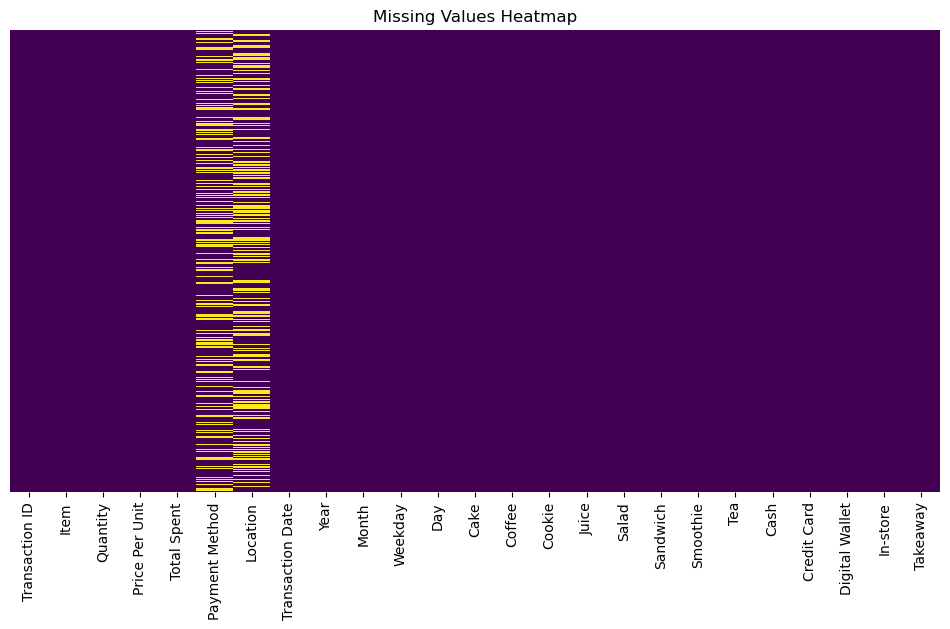

In [ ]:
# Another test to see missingness - looks good!
plt.figure(figsize=(12,6))
sns.heatmap(cafedata.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
# A final sample to get a look at what our imputed data looks like. We're keeping the dummy variables around in case they're needed for future data analysis!
cafedata.sample(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Weekday,Day,Cake,Coffee,Cookie,Juice,Salad,Sandwich,Smoothie,Tea,Cash,Credit Card,Digital Wallet,In-store,Takeaway
2190,TXN_2921765,Tea,2.0,1.5,3.0,Credit Card,Takeaway,2023-09-06,2023.0,9.0,2.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
6164,TXN_6500126,Smoothie,2.0,4.0,8.0,NaN,NaN,2023-03-15,2023.0,3.0,2.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9467,TXN_9517380,Tea,4.0,1.5,6.0,Cash,NaN,2023-10-29,2023.0,10.0,6.0,29.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4979,TXN_5438111,Smoothie,3.0,4.0,12.0,Cash,In-store,2023-01-06,2023.0,1.0,4.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3343,TXN_3963927,Sandwich,4.0,4.0,16.0,Credit Card,In-store,2023-01-03,2023.0,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
7581,TXN_7804488,Cookie,2.0,1.0,2.0,Digital Wallet,NaN,2023-11-28,2023.0,11.0,1.0,28.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8551,TXN_8689416,Juice,5.0,3.0,15.0,NaN,NaN,2023-03-19,2023.0,3.0,6.0,19.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1558,TXN_2371464,Smoothie,4.0,4.0,16.0,Cash,In-store,2023-09-20,2023.0,9.0,2.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
9109,TXN_9191700,Tea,5.0,1.5,7.5,NaN,In-store,2023-10-01,2023.0,10.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1646,TXN_2444408,Sandwich,2.0,4.0,8.0,Digital Wallet,In-store,2023-05-11,2023.0,5.0,3.0,11.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
